In [1]:
import os 
import utils
import test_module
from collections import namedtuple
import numpy as np
import retrieval_run
import settings

## ☁️ 1.  Generating an atmosohere instance 



In [2]:
# Define basic instrument parameters
wavelength_range = [0.95, 2.85]       # Wavelength coverage in microns
Rfile = './examples/example_data/G570D_R_file.txt'  # File with resolving power data
obspec = np.asfortranarray(np.loadtxt("examples/example_data/G570D_2MHcalib.dat",dtype='d',unpack='true'))

# Create an Instrument instance
instrument_instance = utils.Instrument(wavelength_range=wavelength_range, R_file=Rfile,obspec=obspec)
# print(instrument_instance)

In [3]:
# Define basic model parameters
samplemode='multinest'

do_fudge=1
# cloudpath='../cloud_pickles/'

cloudpath="/Users/fw23aao/Downloads/cloud_pickles/"


# Create a ModelConfig instance
model_config_instance = utils.ModelConfig(
    samplemode, do_fudge, cloudpath=cloudpath
)

# Additional settings
model_config_instance.dist = 5.84
model_config_instance.xlist = 'data/gaslistRox.dat'
model_config_instance.xpath = '../../Linelists/'
model_config_instance.do_bff = 0
model_config_instance.update_dictionary()

# print(model_config_instance)


In [4]:
# Create a IO_config instance
io_config_instance = utils.IOConfig()

# Additional settings
io_config_instance.outdir="../fei/test/"
io_config_instance.runname='new_test'
io_config_instance.update_dictionary()

# print(io_config_instance)


In [5]:
# Chemistry setup
chemeq = 0  # 0 = free chemistry, 1 = chemical equilibrium
gaslist = ['h2o', 'co', 'tio', 'vo', 'crh', 'feh', 'na', 'k'] # List of gases included in the retrieval

# Gas type list:
#   'U' = uniform mixing ratio
#   'N' = parameterized vertically varying profile
# This allows different gases to have different vertical distributions

gastype_list = ['U', 'U', 'U', 'U', 'U', 'N', 'U', 'U']

# PT structure
ptype = 77

# Clouds
do_clouds = 1 # Enable or disable cloud modeling, 1 = include clouds, 0 = clear atmosphere
npatches = 2 # Number of atmospheric patches 

# List of all cloud species or parameterized cloud models.
# You can mix empirical clouds (e.g. 'powerlaw', 'grey') and physical Mie scattering clouds.
cloud_name = ['powerlaw', 'grey', 'MgSiO3.mieff']

# Cloud type specifies the geometrical setup:
cloud_type = ['slab', 'deck', 'slab']



# Specify which patch each cloud appears in.
# Each entry in the list corresponds to the same index in `cloud_name`.
# Example:
#   [1]    → only in patch 1
#   [2]    → only in patch 2
#   [1, 2] → appears in both patches

cloudpatch_index = [
    [1],      # 'powerlaw' cloud only in patch 1
    [1, 2],   # 'grey' cloud in both patches
    [1, 2]    # 'MgSiO3.mieff' cloud in both patches
]

# Particle size distribution for each cloud. Use 'None' for parameterized or grey clouds.
# For Mie scattering clouds, specify:'hansen' or 'log_normal' distributions.
particle_dis = ['None', 'None', 'hansen']



#===Clear+Cloudy PATCHY CLOUD SETUP========

"""
# Example of a simpler two-patch setup:
#   - Patch 1: clear
#   - Patch 2: Mie scattering MgSiO3 cloud

npatches = 2
cloud_name = ['clear', 'MgSiO3.mieff']
cloud_type = ['None', 'slab']

cloudpatch_index = [
    [1],  # Clear patch 1
    [2]   # Cloudy patch 2
]

particle_dis = [
    'None',   # Clear atmosphere
    'hansen'  # Mie scattering distribution
]
"""
# ============================

# Create retrieval parameter object, the deafault vrad and vsini are false.
re_params = utils.Retrieval_params(samplemode=samplemode, chemeq=chemeq, gaslist=gaslist,
    gastype_list=gastype_list,do_fudge=do_fudge, ptype=ptype, do_clouds=do_clouds,
    npatches=npatches, cloud_name=cloud_name, cloud_type=cloud_type,
    cloudpatch_index=cloudpatch_index, particle_dis=particle_dis,
    instrument=instrument_instance,vrad=False,vsini=False,fwhm=None)

print(re_params)


args_instance = utils.ArgsGen(re_params,model_config_instance,instrument_instance,obspec)
settings.init(args_instance)
settings.cia = args_instance.cia
settings.linelist= utils.get_opacities(args_instance.gaslist,args_instance.w1,args_instance.w2,args_instance.press,args_instance.xpath,args_instance.xlist,args_instance.malk)
settings.cloudata = args_instance.cloudata

retrieval_param: 
------------
- gas : ['h2o', 'co', 'tio', 'vo', 'crh', 'feh', 'na', 'k']
- refinement_params : ['M', 'R', 'dlambda', 'tolerance_parameter_1']
- pt : ['gamma', 'Tint', 'alpha', 'lndelta', 'T1', 'T2', 'T3']
- cloud : ['fcld', 'patch 1', 'patch 2']
  -- patch 1: ['tau_pcs', 'logp_pcs', 'dp_pcs', 'omega_pcs', 'alpha_pcs', 'logp_gcd', 'dp_gcd', 'omega_gcd', 'tau_mcs_MgSiO3', 'logp_mcs_MgSiO3', 'dp_mcs_MgSiO3', 'hansen_a_mcs_MgSiO3', 'hansen_b_mcs_MgSiO3']
  -- patch 2: ['logp_gcd', 'dp_gcd', 'omega_gcd', 'tau_mcs_MgSiO3', 'logp_mcs_MgSiO3', 'dp_mcs_MgSiO3', 'hansen_a_mcs_MgSiO3', 'hansen_b_mcs_MgSiO3']
- added_params: []



In [6]:
re_params.dictionary

{'gas': {'h2o': {'gastype': 'U',
   'params': {'log_abund': {'initialization': None,
     'MC_init_dis': ['normal', -4.0, 0.5],
     'MC_prior_range': [-12, 0],
     'Multinest_prior': ['centered_log_abund', -12]}}},
  'co': {'gastype': 'U',
   'params': {'log_abund': {'initialization': None,
     'MC_init_dis': ['normal', -4.0, 0.5],
     'MC_prior_range': [-12, 0],
     'Multinest_prior': ['centered_log_abund', -12]}}},
  'tio': {'gastype': 'U',
   'params': {'log_abund': {'initialization': None,
     'MC_init_dis': ['normal', -4.0, 0.5],
     'MC_prior_range': [-12, 0],
     'Multinest_prior': ['centered_log_abund', -12]}}},
  'vo': {'gastype': 'U',
   'params': {'log_abund': {'initialization': None,
     'MC_init_dis': ['normal', -4.0, 0.5],
     'MC_prior_range': [-12, 0],
     'Multinest_prior': ['centered_log_abund', -12]}}},
  'crh': {'gastype': 'U',
   'params': {'log_abund': {'initialization': None,
     'MC_init_dis': ['normal', -4.0, 0.5],
     'MC_prior_range': [-12, 0],
 

## ⚙️ 2. Prior settings

In [7]:
import Priors_new_trial

# Default prior settings:
# Parameters with `Multinest_prior = None` will be post-processed internally within the priors module.
prior_dict = Priors_new_trial.get_all_multinest_priors(re_params.dictionary)
prior_dict

{'h2o': ['centered_log_abund', -12],
 'co': ['centered_log_abund', -12],
 'tio': ['centered_log_abund', -12],
 'vo': ['centered_log_abund', -12],
 'crh': ['centered_log_abund', -12],
 'feh': ['centered_log_abund', -12],
 'p_ref_feh': None,
 'alpha_feh': ['uniform', -5, 5],
 'na': ['centered_log_abund', -12],
 'k': ['centered_log_abund', -12],
 'M': ['uniform', 1.0, 80],
 'R': ['uniform', 0.5, 2.5],
 'dlambda': ['uniform', -0.01, 0.01],
 'tolerance_parameter_1': None,
 'gamma': ['uniform', 0, 5000],
 'Tint': ['uniform', 300, 2300],
 'alpha': ['uniform', 1, 2],
 'lndelta': None,
 'T1': ['uniform', 10, 4010],
 'T2': ['uniform', 10, 4010],
 'T3': ['uniform', 10, 4010],
 'fcld': ['uniform', 0, 1],
 'tau_pcs': ['uniform', 0, 100],
 'logp_pcs': None,
 'dp_pcs': None,
 'omega_pcs': ['uniform', 0, 1],
 'alpha_pcs': ['uniform', -10, 10],
 'logp_gcd': None,
 'dp_gcd': ['uniform', 0, 7],
 'omega_gcd': ['uniform', 0, 1],
 'tau_mcs_MgSiO3': ['uniform', 0, 100],
 'logp_mcs_MgSiO3': None,
 'dp_mcs_MgS

In [8]:
# Check the provided MultiNest prior functions.
Priors_new_trial.query_priors()

['uniform',
 'log_uniform',
 'centered_log_abund',
 'gaussian',
 'truncated_gaussian',
 'Tp77_lndelta']

In [9]:
help(Priors_new_trial.PRIOR_FUNCTIONS['uniform'])

Help on function uniform_prior in module Priors_new_trial:

uniform_prior(r, x1, x2)
    Transform a uniform variable r in [0,1]
    into a uniformly distributed variable x
    between x1 and x2.
    
    Parameters
    ----------
    r : float or array
        Uniform samples between 0 and 1
    
    x1 : float
        Lower bound of the uniform prior
    
    x2 : float
        Upper bound of the uniform prior
    
    Returns
    -------
    x : float or array
        Uniformly distributed samples
        between x1 and x2



In [10]:
help(Priors_new_trial.PRIOR_FUNCTIONS['truncated_gaussian'])

Help on function truncated_gaussian_prior in module Priors_new_trial:

truncated_gaussian_prior(r, mu, sigma, nleft=1, nright=2)
    Transform a uniform variable r in [0,1]
    into an asymmetric truncated Gaussian-distributed variable x.
    
    The Gaussian is truncated to:
    
        [mu - nleft*sigma, mu + nright*sigma]
    
    Parameters
    ----------
    r : float or array
        Uniform samples between 0 and 1
    
    mu : float
        Mean of Gaussian prior
    
    sigma : float
        Standard deviation of Gaussian prior
    
    nleft : float
        Number of sigma below the mean
    
    nright : float
        Number of sigma above the mean
    
    Returns
    -------
    x : float or array
        Asymmetrically truncated Gaussian samples



In [11]:
help(Priors_new_trial.PRIOR_FUNCTIONS['Tp77_lndelta'])

Help on function Tp77_lndelta in module Priors_new_trial:

Tp77_lndelta(r, alpha, press)
    Transform a uniform variable r in [0,1]
    into a logarithmically distributed lndelta
    parameter based on the pressure grid.
    
    Parameters
    ----------
    r : float or array
        Uniform samples between 0 and 1
    
    alpha : float
        Scaling parameter
    
    press : array
        Pressure grid
    
    Returns
    -------
    lndelta : float or array
        Transformed lndelta parameter
    
    Notes
    -----
    If r <= 0, returns -1e32



In [12]:
help(Priors_new_trial.PRIOR_FUNCTIONS['centered_log_abund'])

Help on function centered_log_abundance_prior in module Priors_new_trial:

centered_log_abundance_prior(r, factor, rem)
    Notes
    -----
    Original:
    
        phi = log10(rem) - cube * 12
    
    This revised form generalizes the scaling and centering:
    
        phi = log10(rem) + r * factor
    
    allowing more flexible control of the prior width.



### ⚙️ 2.1 Set Up Priors Specifically for Each Parameter Using Provided Functions

In [13]:
re_params.dictionary['gas']['h2o']['params']['log_abund']['Multinest_prior']=['uniform',-14,0]


### ⚙️ 2.2 Test Whether the MultiNest Unit Cube Is Properly Transformed Using User-Defined Prior Functions

In [14]:
all_params, _ = utils.get_all_parametres(re_params.dictionary)
ndim = len(all_params)
cube = np.random.rand(ndim)

prior_instance = Priors_new_trial.Priors(cube,re_params,args_instance)
phi = prior_instance.priors

In [15]:
params_master = namedtuple('params',all_params)
params_instance = params_master(*phi)
params_instance

params(h2o=-5.429948458346985, co=-5.303155980349581, tio=-5.835007930075727, vo=-7.7845900263307035, crh=-0.5011663530267743, feh=-2.9232077116083417, p_ref_feh=0.5026007083770141, alpha_feh=-1.6443004815229258, na=-1.3222632142231285, k=-2.9866058845127945, M=7.673448167305314, R=2.4595776074146722, dlambda=-0.0059285143817565025, tolerance_parameter_1=-31.5354252598692, gamma=4916.699159744859, Tint=734.7847833599562, alpha=1.531667171571297, lndelta=2.5483388605022155, T1=569.794312595388, T2=2275.1366084927636, T3=2963.0128392214997, fcld=0.10617616855128353, tau_pcs=31.46678053211248, logp_pcs=-2.2279110824234927, dp_pcs=0.25879897521513506, omega_pcs=0.9533916424190509, alpha_pcs=9.791043908047683, logp_gcd=-2.2021226168561103, dp_gcd=0.08604061836312504, omega_gcd=0.4955928372322045, tau_mcs_MgSiO3=52.79255054259997, logp_mcs_MgSiO3=-1.7660760930768258, dp_mcs_MgSiO3=1.9832756474125883, hansen_a_mcs_MgSiO3=2.377988196749456, hansen_b_mcs_MgSiO3=0.2521642999636574)

### ⚙️ 2.3 Final Priors for Each Parameter Used in the Retrieval

In [16]:
print(prior_instance)

All priors considered in the retrieval:
------------
- MultiNest parameter transforms:
  * h2o: ['uniform', -14, 0]
  * co: ['centered_log_abund', -12]
  * tio: ['centered_log_abund', -12]
  * vo: ['centered_log_abund', -12]
  * crh: ['centered_log_abund', -12]
  * feh: ['centered_log_abund', -12]
  * p_ref_feh: Default transform
  * alpha_feh: ['uniform', -5, 5]
  * na: ['centered_log_abund', -12]
  * k: ['centered_log_abund', -12]
  * M: ['uniform', 1.0, 80]
  * R: ['uniform', 0.5, 2.5]
  * dlambda: ['uniform', -0.01, 0.01]
  * tolerance_parameter_1: ['uniform', -38.5372462961704, -27.031785376663613]
  * gamma: ['uniform', 0, 5000]
  * Tint: ['uniform', 300, 2300]
  * alpha: ['uniform', 1, 2]
  * lndelta: ['Tp77_lndelta', 1.531667171571297, 'press']
  * T1: ['uniform', 10, 4010]
  * T2: ['uniform', 10, 4010]
  * T3: ['uniform', 10, 4010]
  * fcld: ['uniform', 0, 1]
  * tau_pcs: ['uniform', 0, 100]
  * logp_pcs: ['uniform', -4.0, 2.300000000000006]
  * dp_pcs: ['uniform', 0, 1.772088

## 3.  🌈 test spectrum

In [47]:
gnostics = 0
trimspec, photspec, tauspec,cfunc = test_module.modelspec(params_instance,re_params,args_instance,gnostics)

<module 'matplotlib.pyplot' from '/Users/fw23aao/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

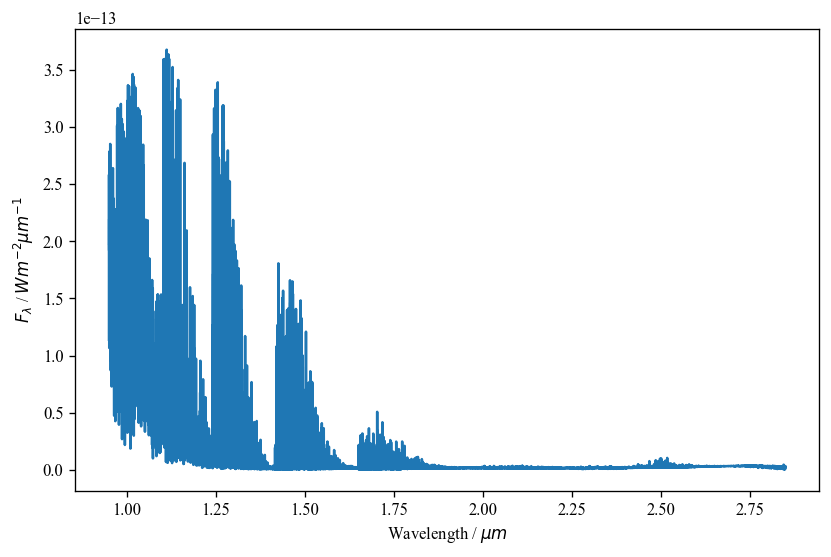

In [48]:
import matplotlib.pyplot as plt
# plot the spectra
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=120,figsize=[8,5])
ax=fig.add_subplot(111)
ax.plot(trimspec[0,:],trimspec[1,:])
plt.ylabel(r'$ F_{\lambda}$ / $Wm^{-2} \mu m^{-1}$')
plt.xlabel('Wavelength / $\mu m$')
plt


<module 'matplotlib.pyplot' from '/Users/fw23aao/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

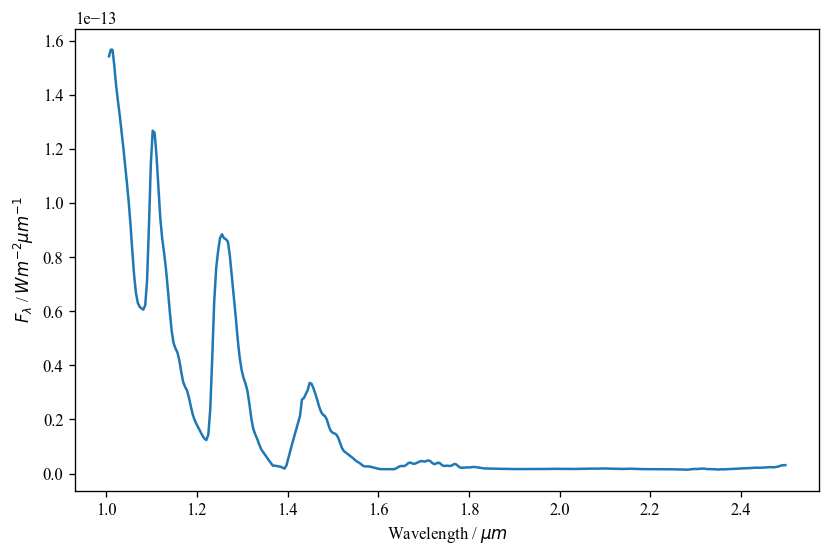

In [50]:
from specops import proc_spec
wave,topspec=proc_spec(inputspec=trimspec, theta=params_instance, re_params=re_params, args_instance=args_instance, do_scales=args_instance.do_scales, do_shift=args_instance.do_shift)

# plot the convolved spectra
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=120,figsize=[8,5])
ax=fig.add_subplot(111)
ax.plot(wave,topspec)
plt.ylabel(r'$ F_{\lambda}$ / $Wm^{-2} \mu m^{-1}$')
plt.xlabel('Wavelength / $\mu m$')
plt